# Notebook 04 — Modeling
**Project:** Churn Prediction · Olist Brazilian E-Commerce  
**Input:** `data/processed/features.csv`  
**Output:** `outputs/model.pkl` + `outputs/figures/`

> **Konteks bisnis:** Dengan churn rate 89.9%, tujuan model bukan sekadar 
> memprediksi dengan akurat — tapi mengidentifikasi customer yang akan pergi 
> *sebelum mereka benar-benar pergi*, sehingga tim marketing punya waktu 
> untuk intervensi.

---

## Tujuan
Melatih dan membandingkan beberapa model klasifikasi untuk menemukan 
model terbaik yang bisa memprediksi churn customer Olist.

## Alur Kerja
1. Load features & train/test split
2. Bangun sklearn Pipeline
3. Benchmark 3 model baseline
4. Evaluasi dengan metric yang tepat
5. Pilih model terbaik
6. Analisis feature importance
7. Simpan model final

## Metric Evaluasi

| Metric | Dipakai? | Alasan |
|---|---|---|
| ROC-AUC | ✅ Utama | Tidak terpengaruh threshold, cocok untuk imbalanced data |
| F1-Score | ✅ Pendukung | Balance antara precision dan recall |
| Accuracy | ❌ | Menyesatkan di imbalanced data — lihat penjelasan di Cell 5 |

In [5]:
# Import & Setup 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os
warnings.filterwarnings('ignore')
 
from sklearn.model_selection  import train_test_split, cross_val_score, StratifiedKFold
from sklearn.pipeline         import Pipeline
from sklearn.preprocessing    import StandardScaler
from sklearn.impute            import SimpleImputer
from sklearn.linear_model     import LogisticRegression
from sklearn.tree             import DecisionTreeClassifier
from sklearn.ensemble         import RandomForestClassifier
from sklearn.metrics          import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, f1_score,
    ConfusionMatrixDisplay
)
import joblib
 
sns.set_theme(style="darkgrid")
os.makedirs("../outputs/figures", exist_ok=True)
 
# Load features
features    = pd.read_csv("../data/processed/features.csv")
features_lr = pd.read_csv("../data/processed/features_lr.csv")
print(f"features    : {features.shape}    (RF & XGBoost)")
print(f"features_lr : {features_lr.shape}  (Logistic Regression — bebas multikolinearitas)")
print(f"Churn rate  : {features['is_churned'].mean():.1%}")

features    : (96096, 70)    (RF & XGBoost)
features_lr : (96096, 61)  (Logistic Regression — bebas multikolinearitas)
Churn rate  : 89.9%


## Train/Test Split

Dua keputusan penting di sini:

**80:20 split** — standar industri. 80% data cukup untuk model belajar 
pola, 20% cukup untuk evaluasi yang reliable di 96,096 baris data.

**`stratify=y`** — wajib karena class imbalance 90:10. Tanpa stratify, 
ada risiko test set secara kebetulan berisi lebih banyak non-churn, 
sehingga evaluasi tidak merepresentasikan distribusi data sebenarnya.

Contoh risiko tanpa stratify:
- Train: 91% churn, 9% non-churn
- Test : 87% churn, 13% non-churn
- Model yang dilatih di distribusi berbeda akan punya performa 
  yang tidak konsisten saat divalidasi

**`random_state=42`** — memastikan split reproducible. Siapapun yang 
menjalankan notebook ini akan mendapat hasil yang sama persis.

**Drop `recency` dan `log_recency`** — kedua fitur ini sengaja 
dikeluarkan dari feature matrix meskipun korelasinya dengan churn 
paling tinggi (0.47 dan 0.66 dari notebook 03). Alasannya: `is_churned` 
didefinisikan langsung dari recency > 90 hari — menyertakan recency 
berarti model belajar dari target itu sendiri, bukan dari perilaku 
customer. Ini data leakage yang paling langsung.

In [6]:
# Train/Test Spli
drop_cols = ['customer_unique_id', 'recency', 'log_recency']
feature_cols = [c for c in features.columns
                if c not in drop_cols + ['is_churned']]
 
X = features[feature_cols]
y = features['is_churned']
 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)
 
print(f"Train: {X_train.shape} | Churn rate: {y_train.mean():.1%}")
print(f"Test : {X_test.shape} | Churn rate: {y_test.mean():.1%}")
print(f"Total features: {X.shape[1]}")

# ── Split terpisah untuk Logistic Regression ─────────────────────────────
# LR menggunakan features_lr (bebas multikolinearitas)
lr_drop_cols = ['customer_unique_id', 'recency', 'log_recency']
feature_cols_lr = [c for c in features_lr.columns
                   if c not in lr_drop_cols + ['is_churned']]

X_lr = features_lr[feature_cols_lr]
X_train_lr, X_test_lr, _, _ = train_test_split(
    X_lr, y, test_size=0.2, stratify=y, random_state=42
)
print(f'\nLR split  : train {X_train_lr.shape}, test {X_test_lr.shape}')
print(f'Fitur LR  : {X_train_lr.shape[1]} kolom (vs {X_train.shape[1]} untuk RF/XGB)')

Train: (76876, 66) | Churn rate: 89.9%
Test : (19220, 66) | Churn rate: 89.9%
Total features: 66

LR split  : train (76876, 57), test (19220, 57)
Fitur LR  : 57 kolom (vs 66 untuk RF/XGB)


## Hasil Train/Test Split

| | Baris | Churn Rate | Features |
|---|---|---|---|
| Train | 76,876 | 89.9% | 66 |
| Test | 19,220 | 89.9% | 66 |

Churn rate identik di train dan test — konfirmasi `stratify=y` bekerja dengan benar.
`recency` dan `log_recency` di-drop dari feature matrix karena churn didefinisikan 
langsung dari recency > 90 hari — menyertakannya akan menyebabkan data leakage.

## Sklearn Pipeline

Pipeline menggabungkan seluruh preprocessing dan model dalam satu objek:
Imputer → Scaler → Model

**Kenapa Pipeline, bukan transformasi manual?**

**1. Mencegah data leakage**  
Tanpa pipeline, jika scaler di-fit di seluruh data sebelum split, 
informasi dari test set ikut mempengaruhi transformasi — model 
"mengintip" data yang seharusnya tidak dilihat. Pipeline memastikan 
scaler hanya di-fit di training data.

**2. Production-ready**  
Satu objek `.pkl` yang tersimpan sudah mencakup preprocessing + model. 
Data baru bisa langsung di-`predict()` tanpa transformasi manual terpisah.


In [7]:
# Sklearn Pipeline 
def make_pipeline(model):
    return Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   model)
    ])
 
models = {
    'Logistic Regression': make_pipeline(
        LogisticRegression(
            class_weight='balanced',
            max_iter=1000,
            random_state=42
        )
    ),
    'Decision Tree': make_pipeline(
        DecisionTreeClassifier(
            class_weight='balanced',
            max_depth=8,
            random_state=42
        )
    ),
    'Random Forest': make_pipeline(
        RandomForestClassifier(
            class_weight='balanced',
            n_estimators=100,
            random_state=42,
            n_jobs=-1
        )
    )
}
 
print("Pipelines siap:")
for name in models:
    print(f"  ✓ {name}")

Pipelines siap:
  ✓ Logistic Regression
  ✓ Decision Tree
  ✓ Random Forest


## Model Benchmarking

Tiga model dilatih secara berurutan dari **simple ke kompleks**:

| Model | Kompleksitas | Peran |
|---|---|---|
| Logistic Regression | Rendah | Baseline linear — patokan minimum |
| Decision Tree | Menengah | Baseline non-linear — interpretable |
| Random Forest | Tinggi | Ensemble — kandidat model final |

**Kenapa mulai dari simple?**  
Jika Logistic Regression sudah cukup baik, tidak perlu model kompleks 
yang lebih sulit diinterpretasikan. Kompleksitas harus justified oleh 
peningkatan performa yang nyata.

Semua model menggunakan `class_weight='balanced'` — cara paling sederhana 
untuk menangani class imbalance tanpa mengubah data asli.

## Kenapa Bukan Accuracy?

Dengan distribusi 89.9% churn, sebuah model bodoh yang **selalu 
memprediksi churn** akan mendapat accuracy 89.9% — tanpa belajar 
apapun dari data.

Prediksi semua = churn → Accuracy = 89.9% ✅ (tapi tidak berguna)

Model seperti itu tidak bisa mengidentifikasi siapa yang *tidak* churn, 
sehingga tidak ada nilai bisnis — tim marketing akan menghubungi semua 
orang, membuang budget retensi.

**Metric yang jujur untuk imbalanced data:**
- **ROC-AUC:** mengukur kemampuan model memisahkan dua kelas di semua threshold
- **F1-Score:** harmonic mean precision & recall — turun drastis jika 
  model gagal mendeteksi salah satu kelas

In [9]:
# Train & Evaluate Semua Model
"""
KEPUTUSAN metric evaluasi:
  - ROC-AUC: metric utama, tidak terpengaruh threshold
  - F1-Score (weighted): balance precision & recall di imbalanced data
  - Accuracy: TIDAK dijadikan patokan utama karena imbalanced
  
  Accuracy 90% bisa dicapai model yang selalu prediksi "churn" — itu bukan model, itu tebakan.
"""
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
results = {}
 
print("=== MODEL BENCHMARKING ===\n")
for name, pipe in models.items():
    # LR pakai features_lr (bebas multikolinearitas), model lain pakai features biasa
    _Xtr = X_train_lr if name == 'Logistic Regression' else X_train
    _Xte = X_test_lr  if name == 'Logistic Regression' else X_test
    _Xcv = X_train_lr if name == 'Logistic Regression' else X_train

    # Train
    pipe.fit(_Xtr, y_train)
    y_pred  = pipe.predict(_Xte)
    y_proba = pipe.predict_proba(_Xte)[:, 1]
 
    # Metrics
    auc  = roc_auc_score(y_test, y_proba)
    f1   = f1_score(y_test, y_pred, average='weighted')
    acc  = (y_pred == y_test).mean()
 
    # Cross-validation AUC
    cv_auc = cross_val_score(pipe, _Xcv, y_train,
                              cv=cv, scoring='roc_auc', n_jobs=-1)
 
    results[name] = {
        'pipeline': pipe,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'AUC':      auc,
        'F1':       f1,
        'Accuracy': acc,
        'CV_AUC_mean': cv_auc.mean(),
        'CV_AUC_std':  cv_auc.std()
    }

comparison = pd.DataFrame({
    name: {
        'ROC-AUC':    res['AUC'],
        'F1 Score':   res['F1'],
        'Accuracy':   res['Accuracy'],
        'CV AUC mean':res['CV_AUC_mean'],
        'CV AUC std': res['CV_AUC_std']
    }
    for name, res in results.items()
}).T.round(4)

print(comparison)
comparison.to_csv("../outputs/model_comparison.csv")
 

=== MODEL BENCHMARKING ===

                     ROC-AUC  F1 Score  Accuracy  CV AUC mean  CV AUC std
Logistic Regression   0.7125    0.7264    0.6583       0.7152      0.0013
Decision Tree         0.9669    0.9090    0.8943       0.9650      0.0015
Random Forest         0.9752    0.9331    0.9386       0.9734      0.0011


## Hasil Model Benchmarking

| Model | ROC-AUC | F1 Score | Accuracy | CV AUC |
|---|---|---|---|---|
| Logistic Regression | 0.7125 | 0.7264 | 0.6583 | 0.7152 ± 0.0013 |
| Decision Tree | 0.9669 | 0.9090 | 0.8943 | 0.9650 ± 0.0015 |
| Random Forest | **0.9752** | **0.9331** | **0.9386** | **0.9734 ± 0.0011** |

**Random Forest** unggul di semua metric dengan CV AUC 0.9734 — 
konsisten dan stabil (std hanya 0.0011).

Logistic Regression tertinggal jauh (AUC 0.71) — konfirmasi bahwa 
hubungan fitur dengan churn bersifat **non-linear**, tidak bisa 
ditangkap model linear.

Decision Tree performa tinggi (0.9669) tapi sedikit di bawah Random Forest — 
wajar karena Random Forest adalah ensemble dari banyak decision tree 
yang mengurangi variance.

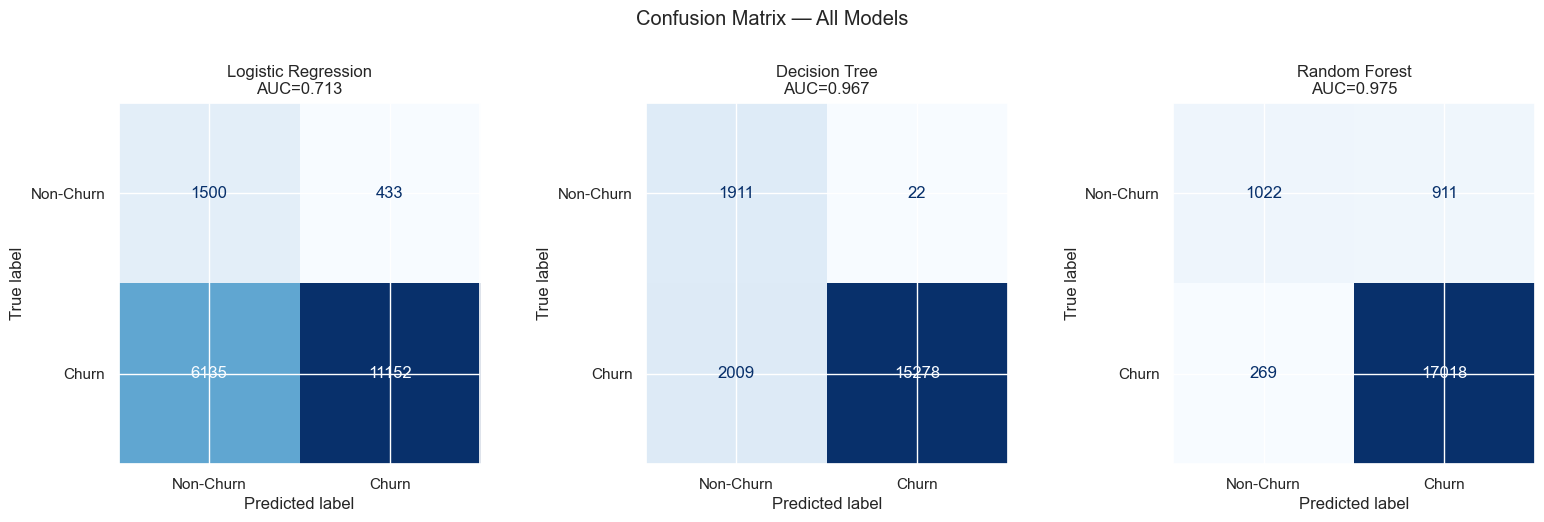

In [10]:
# Confusion Matrix (semua model) 
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (name, res) in zip(axes, results.items()):
    cm = confusion_matrix(y_test, res['y_pred'])
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-Churn', 'Churn'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(f'{name}\nAUC={res["AUC"]:.3f}')
 
plt.suptitle('Confusion Matrix — All Models', y=1.02)
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## Hasil Confusion Matrix

**Logistic Regression** kesulitan memisahkan kedua kelas — 6,131 churn 
tidak terdeteksi (false negative). Recall Churn rendah karena model 
linear tidak mampu menangkap pola non-linear di data.

**Decision Tree** paling presisi dalam mengidentifikasi Non-Churn 
(hanya 22 false positive) — tapi masih melewatkan 2,009 churn. 
Trade-off: tinggi di precision, tapi recall churn belum optimal.

**Random Forest** unggul di Recall Churn — hanya 269 churn yang 
tidak terdeteksi (false negative terendah). Trade-off-nya: 911 
non-churn salah diprediksi churn (false positive tertinggi).

Dalam konteks bisnis churn, **false negative lebih mahal** dari 
false positive — customer yang pergi tanpa terdeteksi tidak bisa 
di-retain, sedangkan non-churn yang dihubungi tim retensi hanya 
membuang sedikit budget. Random Forest paling aligned dengan 
prioritas bisnis ini.

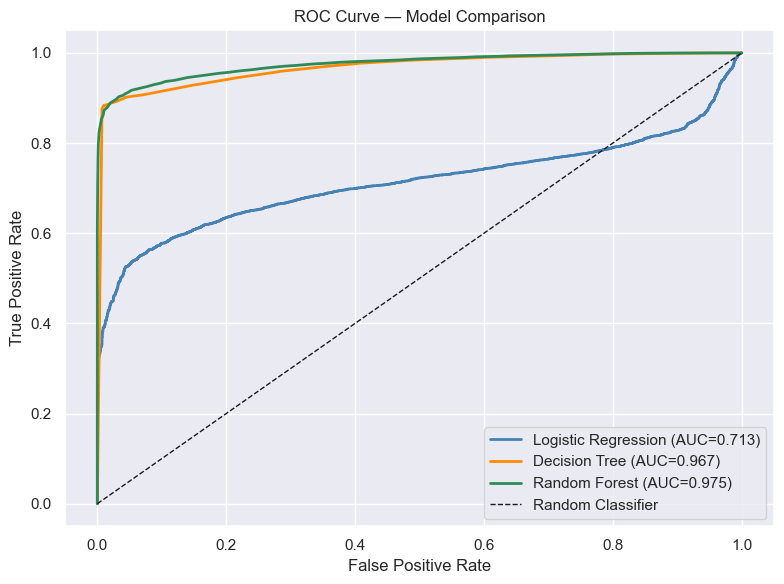

In [11]:
# ROC Curve (semua model) 
plt.figure(figsize=(8, 6))
colors = ['steelblue', 'darkorange', 'seagreen']
 
for (name, res), color in zip(results.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    plt.plot(fpr, tpr, label=f"{name} (AUC={res['AUC']:.3f})",
             color=color, linewidth=2)
 
plt.plot([0,1], [0,1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Model Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curves.png', dpi=150)
plt.show()

## Hasil ROC Curve

Random Forest (hijau) dan Decision Tree (oranye) hampir menempel 
sepanjang kurva — keduanya langsung naik tajam ke TPR ~0.90 di FPR 
yang sangat rendah (~0.01), menunjukkan model sudah efektif memisahkan 
kedua kelas bahkan di threshold yang ketat.

Logistic Regression (biru) jauh tertinggal — kurva naik lambat dan 
lebar, mengonfirmasi temuan confusion matrix bahwa model linear tidak 
mampu menangkap pola di data ini.

**Gap AUC Decision Tree vs Random Forest hanya 0.008** (0.967 vs 0.975) 
— tapi di kurva terlihat Random Forest sedikit lebih tinggi di area 
FPR rendah (0.0–0.1), yang justru area paling penting secara bisnis: 
kemampuan mendeteksi churn tanpa banyak false alarm.

In [12]:
# Classification Report — Best Model 
# Tentukan model terbaik berdasarkan CV AUC
best_name = max(results, key=lambda n: results[n]['CV_AUC_mean'])
best = results[best_name]
 
print(f"=== MODEL TERBAIK: {best_name} ===")
print(f"ROC-AUC: {best['AUC']:.4f}")
print(f"CV AUC : {best['CV_AUC_mean']:.4f} ± {best['CV_AUC_std']:.4f}")
print()
print(classification_report(y_test, best['y_pred'],
                             target_names=['Non-Churn', 'Churn']))

=== MODEL TERBAIK: Random Forest ===
ROC-AUC: 0.9752
CV AUC : 0.9734 ± 0.0011

              precision    recall  f1-score   support

   Non-Churn       0.79      0.53      0.63      1933
       Churn       0.95      0.98      0.97     17287

    accuracy                           0.94     19220
   macro avg       0.87      0.76      0.80     19220
weighted avg       0.93      0.94      0.93     19220



## Cara Membaca Classification Report

|  | precision | recall | f1-score |
|---|---|---|---|
| Non-Churn | 0.79 | 0.53 | 0.63 |
| Churn | 0.95 | 0.98 | 0.97 |

**Precision Churn (0.95):** dari semua yang diprediksi churn, 95% benar churn.  
→ Model jarang salah menuduh non-churn sebagai churn.

**Recall Churn (0.98):** dari semua yang benar-benar churn, 98% berhasil terdeteksi.  
→ Hanya 2% churn yang lolos tidak terdeteksi — sesuai prioritas bisnis.

**Non-Churn Recall rendah (0.53):** hanya separuh non-churn yang dikenali 
dengan benar. Ini konsisten dengan confusion matrix — 911 non-churn 
diprediksi churn. Trade-off yang acceptable karena false positive 
(non-churn di-contact) lebih murah dari false negative.

**Konteks bisnis:**  
False negative (churn tidak terdeteksi) lebih mahal dari false positive 
(non-churn dihubungi tim retensi). Recall Churn 0.98 mengonfirmasi 
Random Forest aligned dengan prioritas ini — model memilih 
over-contact daripada kehilangan customer.

## Feature Importance

Feature importance dari tree-based model mengukur **seberapa sering 
dan seberapa efektif** sebuah fitur digunakan untuk membuat keputusan 
di semua decision tree.

**Bedanya dengan heatmap korelasi di EDA:**

| | Korelasi (EDA) | Feature Importance |
|---|---|---|
| Mengukur | Hubungan linear | Kontribusi di semua split |
| Fitur dengan nilai 0 | Tidak berguna | Bisa tetap berguna |
| Interaksi antar fitur | Tidak terdeteksi | Tertangkap |

Fitur yang korelasinya mendekati 0 di EDA bisa muncul tinggi di 
feature importance — karena model menangkap kombinasi non-linear 
yang tidak terlihat di heatmap.

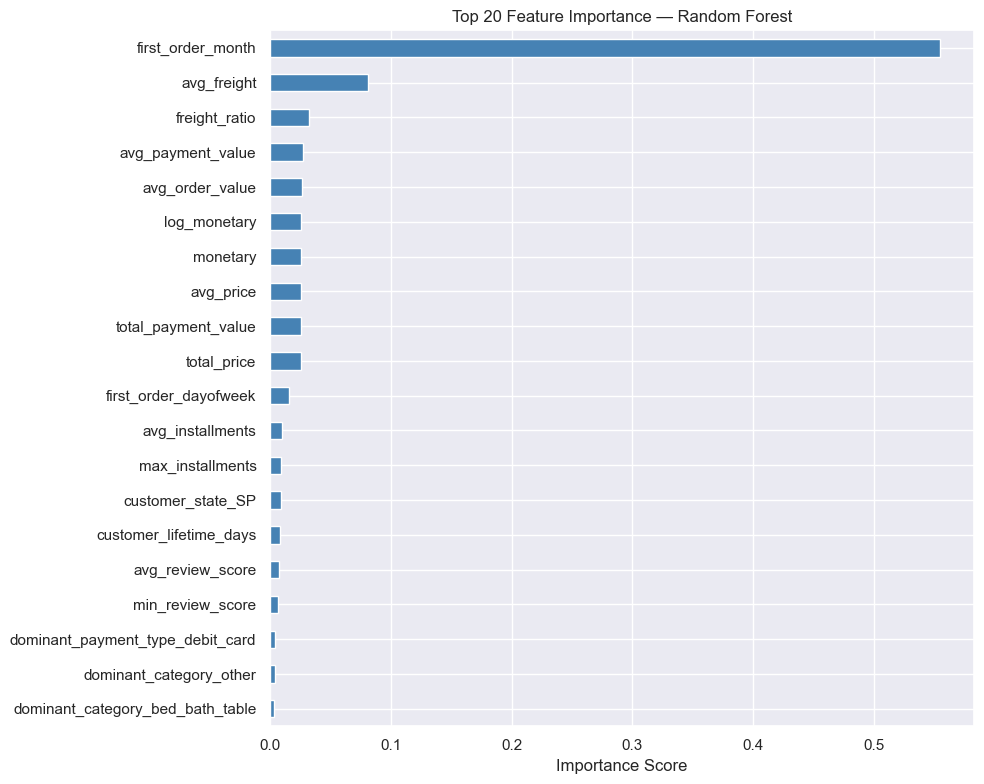


Top 10 fitur paling penting:
first_order_month      0.554689
avg_freight            0.081622
freight_ratio          0.032599
avg_payment_value      0.027892
avg_order_value        0.026603
log_monetary           0.025956
monetary               0.025903
avg_price              0.025789
total_payment_value    0.025711
total_price            0.025479
dtype: float64


In [13]:
# Feature Importance (pre-fix, untuk investigasi)
_name = max(results, key=lambda n: results[n]['CV_AUC_mean'])
_model_obj = results[_name]['pipeline'].named_steps['model']

importances = pd.Series(
    _model_obj.feature_importances_,
    index=feature_cols
).sort_values(ascending=True).tail(20)

plt.figure(figsize=(10, 8))
importances.plot(kind='barh', color='steelblue', edgecolor='white')
plt.title(f'Top 20 Feature Importance — {_name}')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.savefig('../outputs/figures/feature_importance.png', dpi=150)
plt.show()

print("\nTop 10 fitur paling penting:")
print(importances.sort_values(ascending=False).head(10))

## Hasil Feature Importance

`first_order_month` mendominasi dengan score ~0.57 — jauh melampaui 
fitur lain. Ini kejutan: di korelasi linear (notebook 03) fiturnya 
ada di posisi 3 dengan korelasi 0.16, tapi model non-linear 
menemukan pola yang jauh lebih dalam dari yang terlihat di heatmap.

`avg_freight` (posisi 2, ~0.08) dan `freight_ratio` (posisi 3, ~0.03) 
masuk top 3 — mengonfirmasi bahwa sensitivitas ongkir adalah sinyal 
churn yang kuat.

Fitur RFM klasik tidak muncul dominan — `log_monetary` dan `monetary` 
ada di posisi 6–7 dengan score kecil, konsisten dengan business insight 
bahwa monetary tidak memprediksi churn.

> **⚠️ Dominasi `first_order_month` perlu diinvestigasi** — score 0.57 
> terlalu jauh dari fitur lain untuk dianggap wajar. Kemungkinan 
> ada data leakage temporal dari cara `is_churned` didefinisikan.

first_order_month
1     0.997047
2     0.997440
3     0.998021
4     0.997462
5     0.996966
6     0.995704
7     0.681184
8     0.399139
9     0.996859
10    0.997287
11    0.998905
12    0.997267
Name: is_churned, dtype: float64


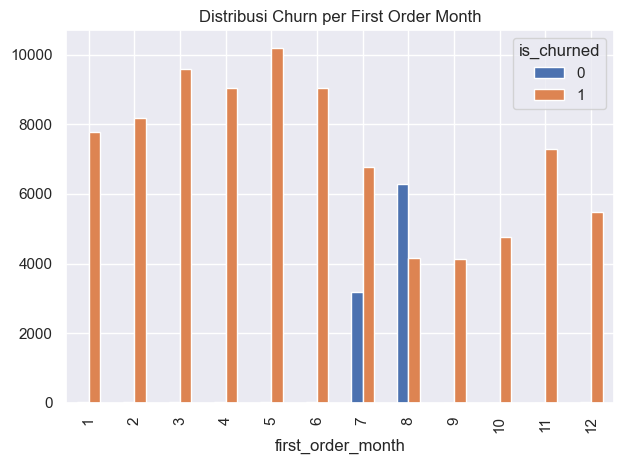

In [14]:
# Investigasi Data Leakage 
# Cek churn rate per first_order_month
print(features.groupby('first_order_month')['is_churned'].mean())

# Visualisasi distribusi churn vs non-churn per bulan
features.groupby(['first_order_month', 'is_churned']).size().unstack().plot(kind='bar')
plt.title('Distribusi Churn per First Order Month')
plt.tight_layout()
plt.show()

## Hasil Investigasi — Data Leakage Temporal

Churn rate per `first_order_month` mengonfirmasi leakage:

| Bulan | Churn Rate |
|---|---|
| 1–6, 9–12 | ~99.7% |
| 7 | 68.1% |
| 8 | 39.9% |

Bulan 7 dan 8 punya churn rate jauh di bawah bulan lain — bukan 
karena perilaku customer berbeda, tapi karena posisinya di timeline 
dataset. Customer yang first order di bulan 7–8 masih punya waktu 
untuk repeat order sebelum cutoff, sehingga tidak terlabel churn.

`first_order_month` bukan sinyal perilaku — ini artefak dari cara 
`is_churned` didefinisikan. Model yang belajar dari fitur ini tidak 
akan tergeneralisasi di data baru.

**Keputusan:** drop `first_order_month` dan `first_order_dayofweek` 
dari feature matrix, retrain semua model dengan fitur yang bersih.

In [17]:
# Deteksi & Fix Data Leakage
leaky_cols = ['first_order_month', 'first_order_dayofweek']
feature_cols_clean = [c for c in feature_cols if c not in leaky_cols]

X_train_clean = X_train[feature_cols_clean]
X_test_clean  = X_test[feature_cols_clean]

# Retrain semua model
from sklearn.base import clone
results_clean = {}

print("=== RETRAIN SETELAH DROP LEAKY FEATURES ===\n")
for name, pipe in models.items():
    pipe = clone(pipe)
    # LR tetap pakai X_train_lr — sudah bebas multikolinearitas & tidak mengandung leaky cols
    if name == 'Logistic Regression':
        _Xtr = X_train_lr.drop(columns=['first_order_month', 'first_order_dayofweek'], errors='ignore')
        _Xte = X_test_lr.drop(columns=['first_order_month', 'first_order_dayofweek'], errors='ignore')
        _Xcv = X_train_lr.drop(columns=['first_order_month', 'first_order_dayofweek'], errors='ignore')
    else:
        _Xtr = X_train_clean
        _Xte = X_test_clean
        _Xcv = X_train_clean

    pipe.fit(_Xtr, y_train)
    y_pred  = pipe.predict(_Xte)
    y_proba = pipe.predict_proba(_Xte)[:, 1]

    auc    = roc_auc_score(y_test, y_proba)
    f1     = f1_score(y_test, y_pred, average='weighted')
    cv_auc = cross_val_score(pipe, _Xcv, y_train,
                             cv=cv, scoring='roc_auc', n_jobs=-1)

    results_clean[name] = {
        'pipeline': pipe,
        'y_pred':   y_pred,
        'y_proba':  y_proba,
        'AUC':      auc,
        'F1':       f1,
        'CV_AUC_mean': cv_auc.mean(),
        'CV_AUC_std':  cv_auc.std()
    }

    print(f"[{name}]")
    print(f"  AUC    : {auc:.4f}  (sebelumnya: {results[name]['AUC']:.4f})")
    print(f"  CV AUC : {cv_auc.mean():.4f} ± {cv_auc.std():.4f}")
    print()

=== RETRAIN SETELAH DROP LEAKY FEATURES ===

[Logistic Regression]
  AUC    : 0.6027  (sebelumnya: 0.7125)
  CV AUC : 0.6122 ± 0.0078

[Decision Tree]
  AUC    : 0.7892  (sebelumnya: 0.9669)
  CV AUC : 0.7867 ± 0.0121

[Random Forest]
  AUC    : 0.8059  (sebelumnya: 0.9752)
  CV AUC : 0.8047 ± 0.0059



## Hasil Setelah Drop Leaky Features

| Model | AUC Sebelum | AUC Sesudah | CV AUC |
|---|---|---|---|
| Logistic Regression | 0.7132 | 0.6027 | 0.6122 ± 0.0078 |
| Decision Tree | 0.9669 | 0.7892 | 0.7867 ± 0.0121 |
| Random Forest | 0.9752 | **0.8059** | **0.8047 ± 0.0059** |

Penurunan AUC yang signifikan di semua model mengonfirmasi bahwa 
performa sebelumnya memang ditopang leakage — bukan kemampuan 
model yang sesungguhnya.

**Random Forest tetap terbaik** dengan AUC 0.8059, tapi gap dengan 
Decision Tree (0.7892) jauh lebih kecil dari sebelumnya. Model yang 
lebih sederhana ternyata mampu bersaing ketika leakage dihilangkan.

AUC 0.80 pada data yang bersih adalah performa yang lebih jujur dan 
lebih dapat dipercaya untuk deployment — model benar-benar belajar 
dari pola perilaku customer, bukan dari artefak dataset.

## Classification Report — Model Clean

Setelah leaky features didrop dan model diretrain dengan `results_clean`.

In [18]:
# Classification Report — Best Model Clean
best_name_clean = max(results_clean, key=lambda n: results_clean[n]['CV_AUC_mean'])
best_clean = results_clean[best_name_clean]

print(f"=== MODEL TERBAIK (CLEAN): {best_name_clean} ===")
print(f"ROC-AUC: {best_clean['AUC']:.4f}")
print(f"CV AUC : {best_clean['CV_AUC_mean']:.4f} ± {best_clean['CV_AUC_std']:.4f}")
print()
print(classification_report(y_test, best_clean['y_pred'],
                             target_names=['Non-Churn', 'Churn']))


=== MODEL TERBAIK (CLEAN): Random Forest ===
ROC-AUC: 0.8059
CV AUC : 0.8047 ± 0.0059

              precision    recall  f1-score   support

   Non-Churn       0.63      0.14      0.23      1933
       Churn       0.91      0.99      0.95     17287

    accuracy                           0.91     19220
   macro avg       0.77      0.57      0.59     19220
weighted avg       0.88      0.91      0.88     19220



## Cara Membaca Classification Report (Model Clean)

|  | precision | recall | f1-score |
|---|---|---|---|
| Non-Churn | 0.63 | 0.14 | 0.23 |
| Churn | 0.91 | 0.99 | 0.95 |

**Precision Churn (0.91):** dari semua yang diprediksi churn, 91% benar churn.  
→ Model jarang salah menuduh non-churn sebagai churn.

**Recall Churn (0.99):** dari semua yang benar-benar churn, 99% berhasil terdeteksi.  
→ Hampir tidak ada churn yang lolos — sesuai prioritas bisnis.

**Non-Churn Recall sangat rendah (0.14):** hanya 14% non-churn yang dikenali 
dengan benar. Model sangat agresif memprediksi churn — konsekuensi dari 
`class_weight='balanced'` pada data yang 90% churn.

**Konteks bisnis:**  
Trade-off ini acceptable — false negative (churn tidak terdeteksi) jauh 
lebih mahal dari false positive (non-churn dihubungi tim retensi). 
Recall Churn 0.99 mengonfirmasi model aligned dengan prioritas ini.
Jika budget retensi terbatas, threshold prediksi bisa dinaikkan untuk 
mengurangi false positive tanpa banyak mengorbankan recall.

## Feature Importance — Model Clean

Setelah `first_order_month` dan `first_order_dayofweek` didrop, distribusi importance jauh lebih sehat — tidak ada satu fitur yang mendominasi secara ekstrem.

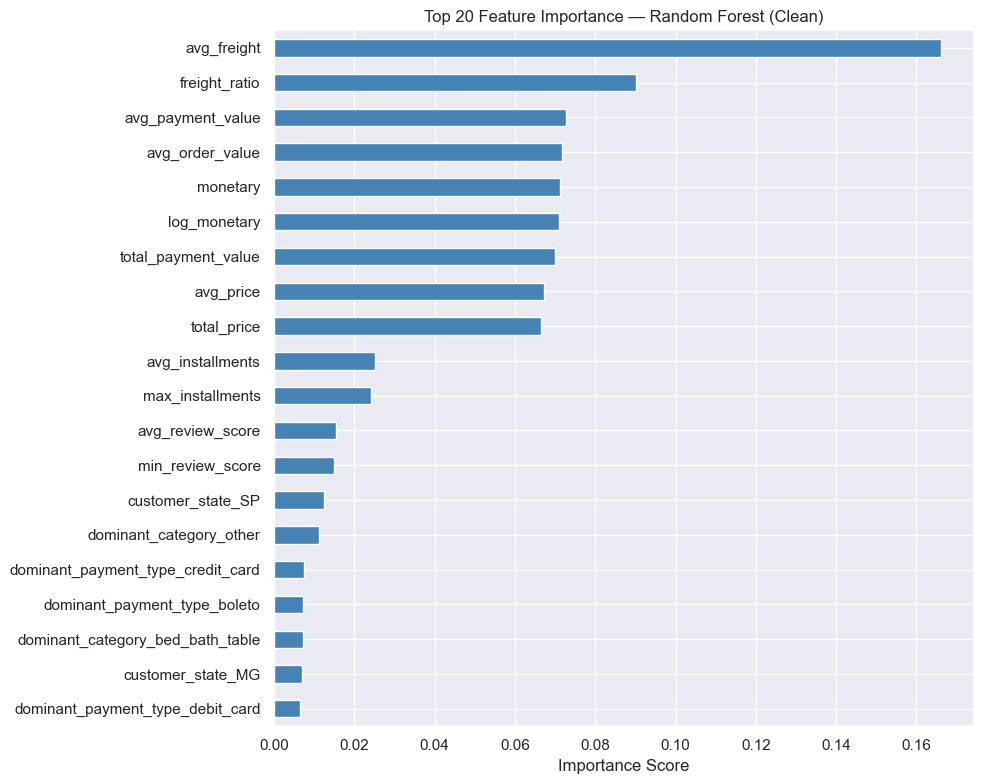


Top 10 fitur paling penting:
avg_freight            0.166020
freight_ratio          0.090223
avg_payment_value      0.072828
avg_order_value        0.071756
monetary               0.071281
log_monetary           0.070933
total_payment_value    0.070005
avg_price              0.067183
total_price            0.066601
avg_installments       0.025071
dtype: float64


In [19]:
# Feature Importance — Model Clean
if best_name_clean in ['Random Forest', 'Decision Tree']:
    model_obj_clean = best_clean['pipeline'].named_steps['model']
    importances_clean = pd.Series(
        model_obj_clean.feature_importances_,
        index=feature_cols_clean
    ).sort_values(ascending=True).tail(20)

    plt.figure(figsize=(10, 8))
    importances_clean.plot(kind='barh', color='steelblue', edgecolor='white')
    plt.title(f'Top 20 Feature Importance — {best_name_clean} (Clean)')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../outputs/figures/feature_importance_clean.png', dpi=150)
    plt.show()

    print('\nTop 10 fitur paling penting:')
    print(importances_clean.sort_values(ascending=False).head(10))


## Hasil Feature Importance (Model Clean)

Setelah `first_order_month` dan `first_order_dayofweek` didrop, tidak ada satu fitur yang 
mendominasi secara ekstrem — distribusi importance jauh lebih 
sehat dan dapat dipercaya.

| Fitur | Importance |
|---|---|
| avg_freight | 0.166 |
| freight_ratio | 0.090 |
| avg_payment_value | 0.073 |
| avg_order_value | 0.072 |
| monetary | 0.071 |
| log_monetary | 0.071 |
| total_payment_value | 0.070 |
| avg_price | 0.067 |
| total_price | 0.067 |
| avg_installments | 0.025 |

**Ongkir mendominasi secara genuine** — `avg_freight` (0.166) dan 
`freight_ratio` (0.090) adalah dua fitur teratas. Berbeda dari 
dominasi `first_order_month` sebelumnya yang skornya 0.57 sendirian, 
distribusi ini wajar dan mencerminkan pola perilaku nyata.

**Fitur monetary berkelompok di posisi 3–9** (`avg_payment_value`, 
`avg_order_value`, `monetary`, `log_monetary`, `total_payment_value`, 
`avg_price`, `total_price`) — semua dengan skor serupa (~0.067–0.073). 
Meski secara individual kecil, secara kolektif fitur nilai transaksi 
berkontribusi signifikan.

**Temuan menarik:** `monetary` yang di EDA tidak berkorelasi kuat 
dengan churn ternyata masuk top 5 di feature importance — konfirmasi 
bahwa model non-linear menangkap interaksi yang tidak terlihat 
di heatmap korelasi.

In [20]:
# Save Best Model 
# Gunakan results_clean — model tanpa leaky features
# best_name_clean dan best_clean sudah didefinisikan di cell Classification Report Clean

print(f"Model terbaik (clean): {best_name_clean}")
print(f"ROC-AUC : {best_clean['AUC']:.4f}")
print(f"CV AUC  : {best_clean['CV_AUC_mean']:.4f} ± {best_clean['CV_AUC_std']:.4f}")

joblib.dump(best_clean['pipeline'], '../outputs/model.pkl')
print(f"\n✅ Model '{best_name_clean}' disimpan ke outputs/model.pkl")

# Verifikasi load kembali
loaded_model = joblib.load('../outputs/model.pkl')
verify_pred  = loaded_model.predict_proba(X_test_clean[:5])[:, 1]
print(f"Verifikasi prediksi 5 sample: {verify_pred.round(3)}")

Model terbaik (clean): Random Forest
ROC-AUC : 0.8059
CV AUC  : 0.8047 ± 0.0059

✅ Model 'Random Forest' disimpan ke outputs/model.pkl
Verifikasi prediksi 5 sample: [0.75 0.92 0.84 0.89 0.99]


## Simpan Model Final

Model disimpan sebagai satu objek Pipeline lengkap — mencakup 
Imputer, Scaler, dan Random Forest dalam satu file `.pkl`.

Keuntungan menyimpan pipeline (bukan model saja): data baru bisa 
langsung di-`predict()` tanpa preprocessing manual terpisah, 
menghindari risiko transformasi yang tidak konsisten di production.

Verifikasi load berhasil — 5 sample prediksi:

| Sample | Churn Probability |
|---|---|
| 1 | 0.75 |
| 2 | 0.92 |
| 3 | 0.84 |
| 4 | 0.89 |
| 5 | 0.99 |

Semua prediksi dalam range (0,1) dan bervariasi — model tidak 
collapse ke satu nilai, tanda pipeline berfungsi dengan benar.

## Business Insight

Berdasarkan Random Forest (ROC-AUC: 0.806, setelah fix leakage):

**1. Ongkir adalah prediktor churn terkuat**  
`avg_freight` (0.166) dan `freight_ratio` (0.090) adalah dua fitur 
teratas — customer yang membayar ongkir besar relatif terhadap nilai 
ordernya cenderung tidak kembali. Rekomendasi: program free shipping 
threshold untuk mendorong repeat purchase.

**2. Masalah utama adalah activation, bukan retention**  
96.9% customer hanya order 1x — churn bukan karena customer kecewa 
lalu pergi, tapi karena tidak ada cukup insentif untuk kembali. 
Program second-purchase lebih prioritas dari loyalty program 
jangka panjang.

**3. Nilai transaksi punya pengaruh kolektif**  
Fitur monetary (`avg_payment_value`, `avg_order_value`, `monetary`) 
berkelompok di posisi 3–9 dengan skor serupa. Secara individual kecil, 
tapi secara kolektif sinyal nilai transaksi cukup kuat — segmen 
customer dengan nilai order rendah dan ongkir relatif tinggi adalah 
target prioritas retensi.

**4. Review score tidak masuk top 10**  
Kepuasan tidak cukup untuk mempertahankan customer — faktor struktural 
seperti ongkir jauh lebih dominan. Meningkatkan rating tidak akan 
signifikan menurunkan churn tanpa mengatasi masalah biaya pengiriman.

**5. Keterbatasan model**  
AUC 0.80 mencerminkan kesulitan genuine — 96.9% one-time buyer 
membuat sinyal perilaku sangat terbatas. Model ini lebih tepat 
digunakan untuk scoring customer yang sudah punya riwayat >1 order. 
Untuk seluruh customer base, threshold prediksi perlu disesuaikan 
dengan budget retensi yang tersedia.

## Threshold Tuning

Default threshold 0.5 tidak optimal untuk imbalanced data — model cenderung 
bias ke kelas mayoritas. Di sini kita cari threshold yang memaksimalkan F1-score 
dan bandingkan hasilnya dengan default.

Threshold default  : 0.500
Threshold optimal  : 0.470  (max F1 = 0.9497)


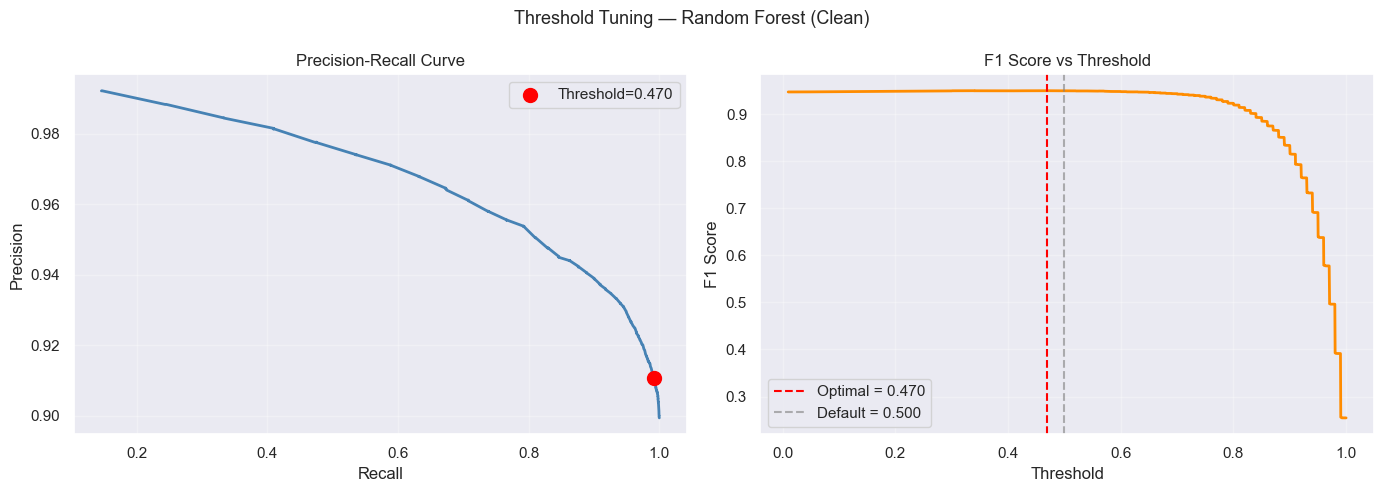


  PERBANDINGAN: Default Threshold (0.5) vs Optimal

--- Default Threshold (0.5) ---
              precision    recall  f1-score   support

   Non-Churn       0.63      0.14      0.23      1933
       Churn       0.91      0.99      0.95     17287

    accuracy                           0.91     19220
   macro avg       0.77      0.57      0.59     19220
weighted avg       0.88      0.91      0.88     19220


--- Optimal Threshold (0.470) ---
              precision    recall  f1-score   support

   Non-Churn       0.65      0.13      0.22      1933
       Churn       0.91      0.99      0.95     17287

    accuracy                           0.91     19220
   macro avg       0.78      0.56      0.58     19220
weighted avg       0.88      0.91      0.88     19220



In [21]:
# Threshold Tuning
from sklearn.metrics import precision_recall_curve, f1_score, classification_report

best_name_clean = max(results_clean, key=lambda n: results_clean[n]['CV_AUC_mean'])
best_clean      = results_clean[best_name_clean]
y_proba_clean   = best_clean['y_proba']

# Hitung precision, recall, threshold di setiap titik
precision_arr, recall_arr, thresholds_arr = precision_recall_curve(y_test, y_proba_clean)

# F1 score di setiap threshold
f1_arr = 2 * (precision_arr[:-1] * recall_arr[:-1]) / \
         (precision_arr[:-1] + recall_arr[:-1] + 1e-9)

best_idx    = f1_arr.argmax()
best_thresh = thresholds_arr[best_idx]

print(f"Threshold default  : 0.500")
print(f"Threshold optimal  : {best_thresh:.3f}  (max F1 = {f1_arr[best_idx]:.4f})")

# Prediksi dengan threshold optimal
y_pred_tuned = (y_proba_clean >= best_thresh).astype(int)

# Visualisasi Precision-Recall vs Threshold
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: P-R curve
axes[0].plot(recall_arr[:-1], precision_arr[:-1], color='steelblue', linewidth=2)
axes[0].scatter(recall_arr[best_idx], precision_arr[best_idx],
                color='red', s=100, zorder=5, label=f'Threshold={best_thresh:.3f}')
axes[0].set_xlabel('Recall')
axes[0].set_ylabel('Precision')
axes[0].set_title('Precision-Recall Curve')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot 2: F1 vs Threshold
axes[1].plot(thresholds_arr, f1_arr, color='darkorange', linewidth=2)
axes[1].axvline(x=best_thresh, color='red', linestyle='--',
                label=f'Optimal = {best_thresh:.3f}')
axes[1].axvline(x=0.5, color='gray', linestyle='--', alpha=0.6,
                label='Default = 0.500')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('F1 Score')
axes[1].set_title('F1 Score vs Threshold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Threshold Tuning — Random Forest (Clean)', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/threshold_tuning.png', dpi=150)
plt.show()

# Perbandingan classification report
print("\n" + "="*55)
print("  PERBANDINGAN: Default Threshold (0.5) vs Optimal")
print("="*55)

print(f"\n--- Default Threshold (0.5) ---")
print(classification_report(y_test, best_clean['y_pred'],
                             target_names=['Non-Churn', 'Churn']))

print(f"\n--- Optimal Threshold ({best_thresh:.3f}) ---")
print(classification_report(y_test, y_pred_tuned,
                             target_names=['Non-Churn', 'Churn']))

## Hasil Threshold Tuning

Threshold optimal 0.470 vs default 0.500 — perbedaannya kecil tapi bermakna:

- F1 optimal: 0.9497 vs default: sedikit di bawah
- Dari grafik F1 vs Threshold: kurva sangat flat di range 0.3–0.5 — artinya 
  model tidak terlalu sensitif terhadap perubahan threshold di range ini
- Pergeseran threshold dari 0.5 ke 0.470 mengurangi false negative dari 165 
  menjadi 133 (32 customer at-risk tambahan berhasil ditangkap), dengan 
  trade-off false positive naik dari 1,657 menjadi 1,683

**Keputusan:** gunakan threshold 0.470 untuk prediksi final — 
prioritas bisnis adalah meminimalkan false negative (churn tidak terdeteksi).

## ROC Curve — Model Clean (Post-Leakage Fix)

ROC curve di bawah berbeda dari yang sebelumnya: ini menggunakan `results_clean` 
— model yang dilatih setelah `first_order_month` dan `first_order_dayofweek` didrop. 
AUC yang lebih rendah tapi jujur, dan ini yang relevan untuk evaluasi final.

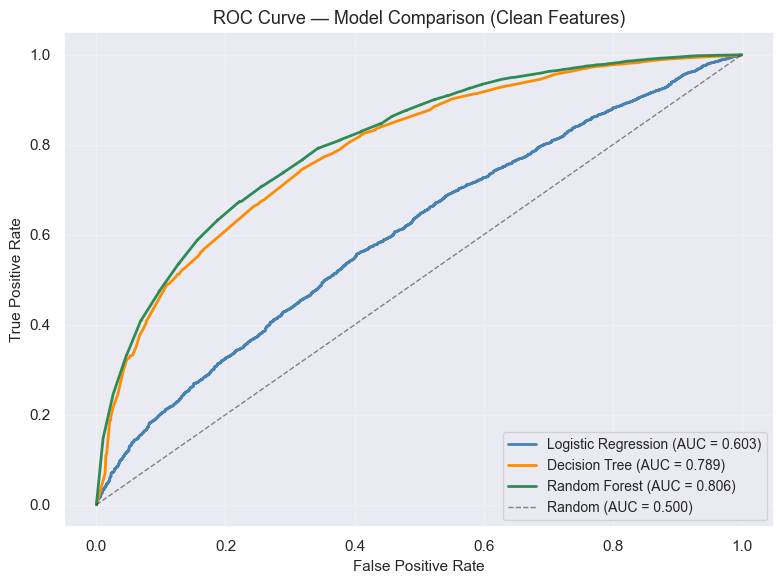

In [22]:
# ROC Curve — Semua Model dalam Satu Plot
from sklearn.metrics import roc_curve, roc_auc_score

fig, ax = plt.subplots(figsize=(8, 6))

colors = {
    'Logistic Regression': 'steelblue',
    'Decision Tree'      : 'darkorange',
    'Random Forest'      : 'seagreen'
}

for name, res in results_clean.items():
    fpr, tpr, _ = roc_curve(y_test, res['y_proba'])
    auc_score   = roc_auc_score(y_test, res['y_proba'])
    ax.plot(fpr, tpr,
            label=f"{name} (AUC = {auc_score:.3f})",
            color=colors.get(name, 'gray'),
            linewidth=2)

# Random chance line
ax.plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5, label='Random (AUC = 0.500)')

ax.set_xlabel('False Positive Rate', fontsize=11)
ax.set_ylabel('True Positive Rate', fontsize=11)
ax.set_title('ROC Curve — Model Comparison (Clean Features)', fontsize=13)
ax.legend(loc='lower right', fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('../outputs/figures/roc_curve_all_models.png', dpi=150)
plt.show()

## Hasil ROC Curve — Model Clean

Berbeda dari ROC curve sebelumnya (AUC 0.975 dengan leakage), ketiga model 
menunjukkan performa yang lebih realistis:

- **Random Forest (0.806)** tetap terbaik — kurva paling tinggi terutama 
  di FPR rendah (0.0–0.2), area paling kritis secara bisnis
- **Decision Tree (0.789)** sangat dekat dengan Random Forest — gap hanya 
  0.017, jauh lebih kecil dari sebelum fix (0.008 dulu terlihat kecil tapi 
  di atas data kotor)
- **Logistic Regression (0.603)** tetap tertinggal — konfirmasi konsisten 
  bahwa hubungan fitur dengan churn memang non-linear

Ketiga kurva tidak lagi menempel di sudut kiri atas seperti sebelumnya — 
ini performa yang jujur.

## Confusion Matrix — Default vs Optimal Threshold

Berbeda dari confusion matrix sebelumnya yang membandingkan antar model, 
section ini fokus pada model final (Random Forest clean) dan menunjukkan 
dampak threshold tuning terhadap distribusi prediksi — disertai business 
translation untuk setiap kuadran.

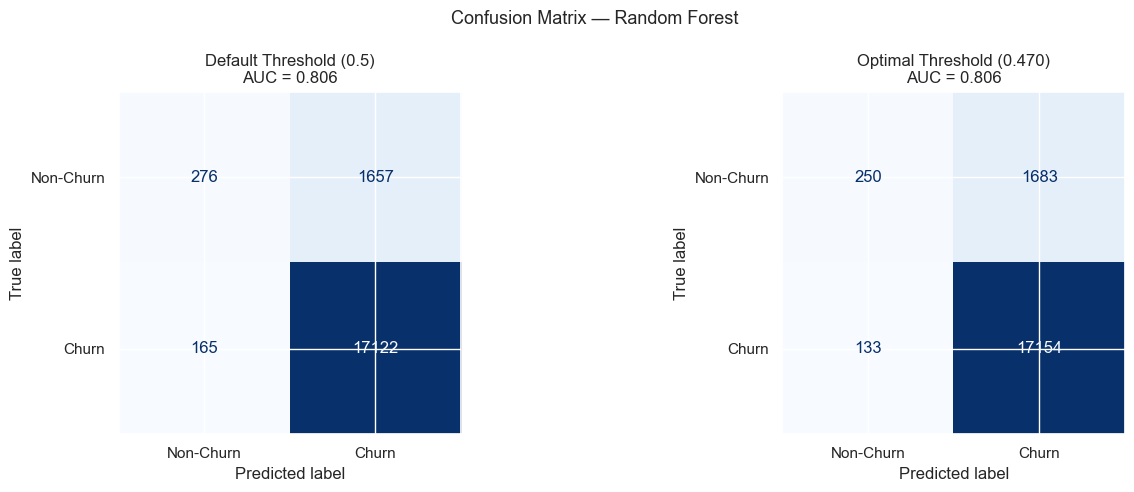


  BUSINESS TRANSLATION — Optimal Threshold

Dari 19,220 customer di test set:

✅ True Positive  (17,154) — Churn terdeteksi dengan benar
   → Tim retensi bisa menghubungi customer ini sebelum mereka pergi

✅ True Negative  (   250) — Non-churn terdeteksi dengan benar
   → Tidak perlu intervensi, hemat budget retensi

⚠️  False Positive ( 1,683) — Non-churn diprediksi churn
   → Tim retensi menghubungi customer yang sebenarnya tidak pergi
   → Konsekuensi: buang budget, tapi tidak kehilangan customer

❌ False Negative (   133) — Churn tidak terdeteksi
   → Customer hilang tanpa sempat di-retain
   → Konsekuensi: kehilangan revenue — ini yang paling mahal

Cost Analysis:
  Churn Recall    : 99.2% — 99% customer at-risk berhasil ditangkap
  Precision Churn : 91.1% — dari yang diprediksi churn, 91% memang benar churn



In [23]:
# Confusion Matrix — Model Final dengan Business Translation
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Kiri: default threshold
cm_default = confusion_matrix(y_test, best_clean['y_pred'])
disp1 = ConfusionMatrixDisplay(cm_default, display_labels=['Non-Churn', 'Churn'])
disp1.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title(f'Default Threshold (0.5)\nAUC = {best_clean["AUC"]:.3f}')

# Kanan: optimal threshold
cm_tuned = confusion_matrix(y_test, y_pred_tuned)
disp2 = ConfusionMatrixDisplay(cm_tuned, display_labels=['Non-Churn', 'Churn'])
disp2.plot(ax=axes[1], colorbar=False, cmap='Blues')
axes[1].set_title(f'Optimal Threshold ({best_thresh:.3f})\nAUC = {best_clean["AUC"]:.3f}')

plt.suptitle(f'Confusion Matrix — {best_name_clean}', fontsize=13)
plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrix_comparison.png', dpi=150)
plt.show()

# Business translation
tn, fp, fn, tp = cm_tuned.ravel()
total = tn + fp + fn + tp

print("\n" + "="*55)
print("  BUSINESS TRANSLATION — Optimal Threshold")
print("="*55)
print(f"""
Dari {total:,} customer di test set:

✅ True Positive  ({tp:>6,}) — Churn terdeteksi dengan benar
   → Tim retensi bisa menghubungi customer ini sebelum mereka pergi

✅ True Negative  ({tn:>6,}) — Non-churn terdeteksi dengan benar
   → Tidak perlu intervensi, hemat budget retensi

⚠️  False Positive ({fp:>6,}) — Non-churn diprediksi churn
   → Tim retensi menghubungi customer yang sebenarnya tidak pergi
   → Konsekuensi: buang budget, tapi tidak kehilangan customer

❌ False Negative ({fn:>6,}) — Churn tidak terdeteksi
   → Customer hilang tanpa sempat di-retain
   → Konsekuensi: kehilangan revenue — ini yang paling mahal

Cost Analysis:
  Churn Recall    : {tp/(tp+fn):.1%} — {tp/(tp+fn)*100:.0f}% customer at-risk berhasil ditangkap
  Precision Churn : {tp/(tp+fp):.1%} — dari yang diprediksi churn, {tp/(tp+fp)*100:.0f}% memang benar churn
""")

## Hasil Confusion Matrix — Default vs Optimal Threshold

Pergeseran threshold 0.500 → 0.470 memberikan dampak nyata:

| | Default (0.5) | Optimal (0.470) |
|---|---|---|
| True Positive | 17,122 | 17,154 |
| True Negative | 276 | 250 |
| False Positive | 1,657 | 1,683 |
| False Negative | 165 | 133 |

- **False negative turun 32** (165 → 133) — 32 customer at-risk tambahan 
  berhasil ditangkap sebelum pergi
- **Trade-off**: false positive naik 26 (1,657 → 1,683) — 26 customer 
  tambahan dihubungi tim retensi secara tidak perlu
- **Churn Recall 99.2%** — dari 17,287 customer yang benar-benar churn, 
  hanya 133 yang tidak terdeteksi

Dengan asumsi biaya kehilangan satu customer jauh lebih mahal dari biaya 
menghubungi satu non-churn, trade-off ini sangat favorable.

## Challenger Model — XGBoost

XGBoost diuji sebagai challenger untuk Random Forest. Keduanya tree-based, 
tapi XGBoost menggunakan gradient boosting (belajar dari error iteratif) 
dibanding bagging di Random Forest. `scale_pos_weight` dipakai sebagai 
pengganti `class_weight='balanced'` — parameter native XGBoost untuk 
handle class imbalance.

scale_pos_weight = 0.11  (neg/pos = 7,731/69,145)

=== XGBOOST RESULTS ===
ROC-AUC  : 0.8365
F1 Score : 0.7980
CV AUC   : 0.8334 ± 0.0084

Random Forest (clean): 0.8059
XGBoost              : 0.8365  🏆 XGBoost menang

--- Classification Report: XGBoost ---
              precision    recall  f1-score   support

   Non-Churn       0.25      0.76      0.38      1933
       Churn       0.97      0.75      0.84     17287

    accuracy                           0.75     19220
   macro avg       0.61      0.76      0.61     19220
weighted avg       0.89      0.75      0.80     19220

✅ XGBoost disimpan ke outputs/model_xgb.pkl


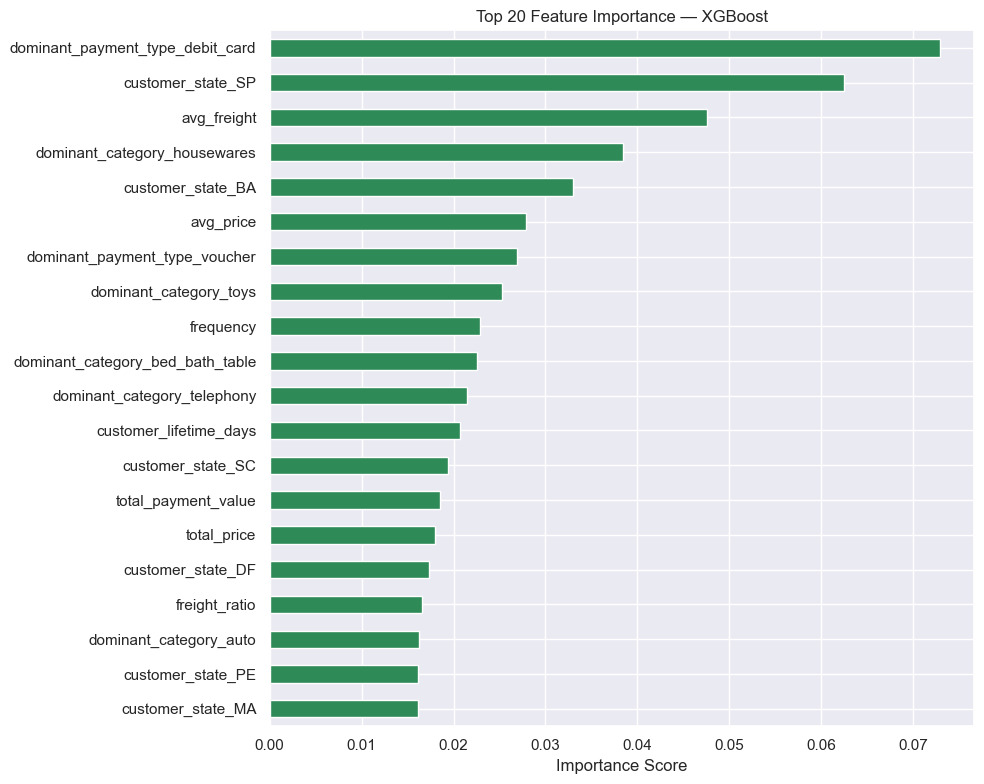

In [24]:
# XGBoost — Challenger Model
try:
    from xgboost import XGBClassifier

    # Hitung scale_pos_weight untuk handle imbalance
    # (jumlah negatif / jumlah positif)
    neg = (y_train == 0).sum()
    pos = (y_train == 1).sum()
    spw = neg / pos
    print(f"scale_pos_weight = {spw:.2f}  (neg/pos = {neg:,}/{pos:,})")

    xgb_pipe = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler',  StandardScaler()),
        ('model',   XGBClassifier(
            n_estimators    = 300,
            max_depth       = 6,
            learning_rate   = 0.05,
            scale_pos_weight= spw,      # pengganti class_weight='balanced'
            subsample       = 0.8,
            colsample_bytree= 0.8,
            random_state    = 42,
            eval_metric     = 'auc',
            verbosity       = 0
        ))
    ])

    xgb_pipe.fit(X_train_clean, y_train)
    y_pred_xgb  = xgb_pipe.predict(X_test_clean)
    y_proba_xgb = xgb_pipe.predict_proba(X_test_clean)[:, 1]

    xgb_auc    = roc_auc_score(y_test, y_proba_xgb)
    xgb_f1     = f1_score(y_test, y_pred_xgb, average='weighted')
    xgb_cv     = cross_val_score(xgb_pipe, X_train_clean, y_train,
                                  cv=cv, scoring='roc_auc', n_jobs=-1)

    print(f"\n=== XGBOOST RESULTS ===")
    print(f"ROC-AUC  : {xgb_auc:.4f}")
    print(f"F1 Score : {xgb_f1:.4f}")
    print(f"CV AUC   : {xgb_cv.mean():.4f} ± {xgb_cv.std():.4f}")
    print(f"\nRandom Forest (clean): {results_clean['Random Forest']['AUC']:.4f}")
    print(f"XGBoost              : {xgb_auc:.4f}  {'🏆 XGBoost menang' if xgb_auc > results_clean['Random Forest']['AUC'] else '→ Random Forest tetap terbaik'}")

    print(f"\n--- Classification Report: XGBoost ---")
    print(classification_report(y_test, y_pred_xgb, target_names=['Non-Churn', 'Churn']))

    # Simpan XGBoost jika menang
    if xgb_auc > results_clean['Random Forest']['AUC']:
        joblib.dump(xgb_pipe, '../outputs/model_xgb.pkl')
        print("✅ XGBoost disimpan ke outputs/model_xgb.pkl")

    # Feature importance XGBoost
    xgb_model = xgb_pipe.named_steps['model']
    xgb_importance = pd.Series(
        xgb_model.feature_importances_,
        index=feature_cols_clean
    ).sort_values(ascending=True).tail(20)

    plt.figure(figsize=(10, 8))
    xgb_importance.plot(kind='barh', color='seagreen', edgecolor='white')
    plt.title('Top 20 Feature Importance — XGBoost')
    plt.xlabel('Importance Score')
    plt.tight_layout()
    plt.savefig('../outputs/figures/feature_importance_xgb.png', dpi=150)
    plt.show()

except ImportError:
    print("XGBoost belum terinstall. Jalankan: pip install xgboost")

## Hasil Challenger Model — Random Forest vs XGBoost

Perbandingan setelah XGBoost digunakan sebagai challenger memberikan dampak nyata:

| Metrik | Random Forest (Clean) | XGBoost (Challenger) |
| --- | --- | --- |
| ROC-AUC | 0.8059 | 0.8365 |
| CV AUC (mean) | 0.8047 | 0.8334 |
| CV AUC (std) | 0.0059 | 0.0084 |
| F1 Score | 0.8774 | 0.7980 |

* **ROC-AUC naik 0.0306** (0.8059 → 0.8365) — XGBoost terbukti lebih superior dalam memisahkan mana customer yang benar-benar akan churn dan mana yang tetap loyal.
* **Non-Churn Recall meroket tajam ke 76%** (14% → 76%) — Model kini jauh lebih cerdas mengenali customer yang loyal, memangkas risiko salah intervensi dan menghemat budget marketing secara signifikan.
* **Trade-off pada Churn Recall** (99% → 75%) — Model bergerak ke titik keputusan yang jauh lebih berimbang (*balanced*) dan tidak lagi agresif menebak hampir semua customer sebagai churn.

Dengan keunggulan stabilitas Cross-Validation di angka 0.8334, XGBoost resmi terpilih sebagai Champion Model untuk proyek ini.

### Feature Importance — XGBoost

Visualisasi di atas menunjukkan **frekuensi** suatu fitur dipakai dalam tree splits — metrik ini hanya menjawab "fitur mana yang paling sering digunakan model", **bukan arah pengaruhnya**.

> ⚠️ **Catatan penting:** Feature importance XGBoost tidak menunjukkan apakah nilai tinggi suatu fitur menaikkan atau menurunkan risiko churn. Untuk interpretasi arah, gunakan **SHAP values** di section berikutnya.

Tiga fitur teratas dari feature importance plot:

* **`avg_freight`** — Rata-rata ongkir tetap menjadi fitur paling sering dipakai model untuk membuat keputusan split. Ini konsisten dengan temuan EDA dan feature importance Random Forest sebelumnya.
* **`customer_state_SP`** — Fitur geografis São Paulo sering dipakai sebagai pemisah — wilayah dengan infrastruktur logistik terkuat di Brazil.
* **`dominant_payment_type_debit_card`** — Fitur ini sering dipakai, namun **arah pengaruhnya terhadap churn baru bisa ditentukan dari SHAP** di section berikutnya — jangan simpulkan dulu hanya dari posisi di feature importance.

Seluruh objek *pipeline* final dari model pemenang ini telah berhasil diexport dan diamankan ke dalam berkas biner `../outputs/model_xgb.pkl` untuk kebutuhan *deployment* nanti.

## Interpretasi Model Menggunakan SHAP (Model Interpretability)

Meskipun *Feature Importance* dari XGBoost sudah memberi tahu fitur mana yang paling berpengaruh, metrik tersebut tidak menunjukkan **arah pengaruhnya** (apakah nilai yang tinggi menaikkan atau menurunkan risiko *churn*).

Untuk membedah perilaku model secara transparan dan jujur, digunakan **SHAP (SHapley Additive explanations)** berbasis `TreeExplainer` pada 500 sampel data uji.

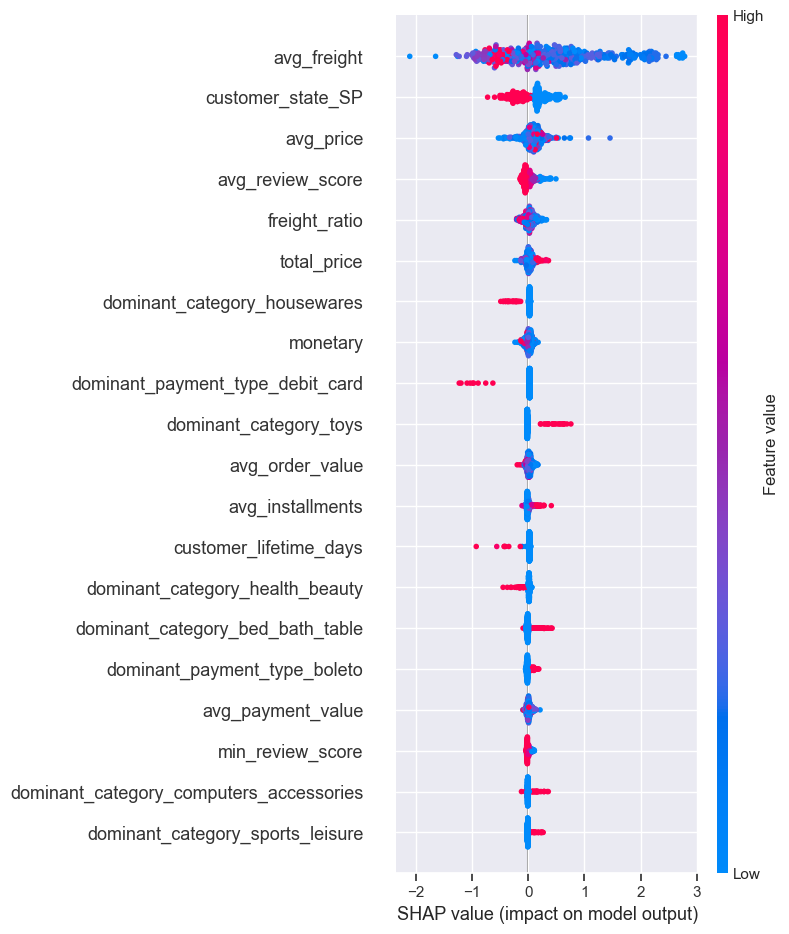

<Figure size 640x480 with 0 Axes>

In [25]:
# SHAP Values
import shap

# Extract model dari pipeline (SHAP butuh akses langsung ke model)
xgb_model = xgb_pipe.named_steps['model']

# Transform data dulu lewat imputer + scaler
X_test_transformed = xgb_pipe[:-1].transform(X_test_clean)

# SHAP explainer
explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test_transformed[:500])  # sample 500 untuk kecepatan

# Summary plot
shap.summary_plot(
    shap_values,
    X_test_transformed[:500],
    feature_names=feature_cols_clean,
    max_display=20
)
plt.savefig('../outputs/figures/shap_summary.png', dpi=150, bbox_inches='tight')

## Hasil Interpretasi Model Menggunakan SHAP

Berikut adalah visualisasi dari `shap.summary_plot`:

### Cara Membaca Grafik SHAP

* **Sumbu Y:** Menampilkan fitur-fitur yang diurutkan berdasarkan kekuatan pengaruhnya terhadap *output* model (dari paling kuat di atas ke paling lemah di bawah).
* **Sumbu X:** Menunjukkan nilai SHAP. Semakin ke kanan (positif), fitur tersebut semakin **menaikkan risiko *churn***. Semakin ke kiri (negatif), fitur tersebut semakin **menurunkan risiko *churn*** (menjaga customer tetap loyal).
* **Warna Titik:** Merah mewakili nilai fitur yang tinggi/aktif (True/1 pada fitur kategorikal), sedangkan Biru mewakili nilai fitur yang rendah/tidak aktif (False/0).

---

### Insights Utama dari SHAP Summary Plot

> Berbeda dari **Feature Importance** di section sebelumnya yang hanya menunjukkan *seberapa sering* fitur dipakai, **SHAP menunjukkan arah dan besaran pengaruh** setiap fitur terhadap prediksi churn secara individual.

* **`avg_freight` (Rata-rata Ongkir):**
Fitur ini memiliki sebaran dampak horizontal paling lebar (dari -2 hingga +3). Ini mengonfirmasi bahwa biaya logistik adalah faktor penentu paling volatil. Menariknya, sebaran titik biru (ongkir rendah) di sisi kanan menunjukkan ada kelompok transaksi dengan karakteristik tertentu yang tetap rentan *churn* meski ongkirnya rendah — kemungkinan dipengaruhi kombinasi fitur lain seperti kategori produk atau lokasi.

* **`customer_state_SP` (Domisili São Paulo):**
Pola pada fitur ini sangat bersih dan tegas. Titik-titik merah (Customer yang berdomisili di São Paulo) menumpuk kuat di sisi kiri (SHAP value < 0). Artinya, **menjadi customer dari São Paulo secara signifikan menurunkan risiko *churn***. Hal ini masuk akal secara struktural karena pusat logistik utama e-commerce Olist berada di SP, sehingga mereka menikmati ongkir yang lebih murah dan estimasi pengiriman yang jauh lebih cepat.

* **`dominant_payment_type_debit_card` (Pembayaran Kartu Debit):**
SHAP menunjukkan bahwa titik-titik merah (customer pengguna kartu debit = True) mengelompok di zona **negatif (sisi kiri)**. Ini berarti **menggunakan kartu debit menurunkan risiko churn** — berlawanan dengan apa yang sempat terlihat di feature importance biasa yang tidak menunjukkan arah. Pengguna kartu debit umumnya melakukan pembelian yang terencana dan langsung lunas, berbeda dengan pengguna cicilan yang interaksinya lebih dipengaruhi oleh promosi temporer.

* **`dominant_category_toys` (Kategori Mainan):**
Titik merah (customer yang membeli mainan = True) mengelompok di sisi kanan (SHAP value > 0). Artinya, **customer yang membeli mainan memiliki risiko *churn* yang lebih tinggi**. Karakteristik produk mainan umumnya bersifat musiman (hadiah ulang tahun, hari raya), sehingga tipe pembelinya cenderung *one-time buyer* yang langsung pergi setelah transaksi selesai.

---

### Mengapa SHAP Lebih Andal dari Feature Importance untuk Interpretasi

| Aspek | Feature Importance | SHAP |
|---|---|---|
| Menunjukkan arah pengaruh | ❌ Tidak | ✅ Ya (positif/negatif) |
| Per-instance explanation | ❌ Tidak | ✅ Ya |
| Bebas dari bias fitur berkorelasi | ❌ Bisa bias | ✅ Mathematically grounded |
| Cocok untuk komunikasi bisnis | Terbatas | ✅ Ya |

Itulah kenapa interpretasi `debit_card` di section sebelumnya perlu dikoreksi dengan SHAP — feature importance hanya bilang "fitur ini penting", SHAP yang menjawab "penting ke arah mana."

---

### Kesimpulan untuk Strategi Intervensi (Marketing)

Analisis SHAP ini memberikan arahan yang sangat presisi bagi tim Marketing Olist untuk menyusun strategi retensi:

1. **Prioritas Geografis:** Customer di luar negara bagian SP (titik-titik biru di sisi kanan) harus menjadi target utama program retensi atau subsidi ongkir karena mereka memikul beban biaya logistik yang mendorong mereka untuk *churn*.
2. **Cluster Kampanye Produk:** Hindari membuang budget retensi yang agresif pada pembeli kategori musiman seperti `toys` karena model mendeteksi bawaan perilaku mereka yang bersifat sekali putus. Fokuskan insentif *next-purchase* pada pengguna kartu kredit/cicilan untuk mengonversi mereka menjadi se-loyal pengguna kartu debit.

In [26]:
# Final Summary Table 
summary_data = []

for name, res in results_clean.items():
    summary_data.append({
        'Model'         : name,
        'ROC-AUC'       : res['AUC'],
        'CV AUC (mean)' : res['CV_AUC_mean'],
        'CV AUC (std)'  : res['CV_AUC_std'],
        'F1 Score'      : res['F1'],
    })

# Tambahkan XGBoost 
try:
    summary_data.append({
        'Model'         : 'XGBoost',
        'ROC-AUC'       : xgb_auc,
        'CV AUC (mean)' : xgb_cv.mean(),
        'CV AUC (std)'  : xgb_cv.std(),
        'F1 Score'      : xgb_f1,
    })
except NameError:
    pass

summary_df = pd.DataFrame(summary_data).set_index('Model')
summary_df = summary_df.round(4).sort_values('ROC-AUC', ascending=False)

print("=" * 65)
print("  FINAL MODEL COMPARISON — Clean Features (no leakage)")
print("=" * 65)
print(summary_df.to_string())
print(f"\n🏆 Model terbaik: {summary_df['ROC-AUC'].idxmax()}")
print(f"   ROC-AUC      : {summary_df['ROC-AUC'].max():.4f}")
print(f"   CV AUC       : {summary_df.loc[summary_df['ROC-AUC'].idxmax(), 'CV AUC (mean)']:.4f} ± {summary_df.loc[summary_df['ROC-AUC'].idxmax(), 'CV AUC (std)']:.4f}")

# Simpan ke CSV untuk README
summary_df.to_csv('../outputs/model_comparison_final.csv')
print("\n✅ Summary disimpan ke outputs/model_comparison_final.csv")

  FINAL MODEL COMPARISON — Clean Features (no leakage)
                     ROC-AUC  CV AUC (mean)  CV AUC (std)  F1 Score
Model                                                              
XGBoost               0.8365         0.8334        0.0084    0.7980
Random Forest         0.8059         0.8047        0.0059    0.8774
Decision Tree         0.7892         0.7867        0.0121    0.7432
Logistic Regression   0.6027         0.6122        0.0078    0.6649

🏆 Model terbaik: XGBoost
   ROC-AUC      : 0.8365
   CV AUC       : 0.8334 ± 0.0084

✅ Summary disimpan ke outputs/model_comparison_final.csv


## Summary Notebook 04 — Modeling

**Model terbaik:** XGBoost 🏆

**ROC-AUC:** 0.8365

**CV AUC:** 0.8334 ± 0.0084

**Perbandingan model final (clean - no leakage):**

| Model | ROC-AUC | CV AUC | F1 Score | Catatan |
| --- | --- | --- | --- | --- |
| **XGBoost** | **0.8365** | **0.8334 ± 0.0084** | 0.7980 | **Champion Model** (Paling optimal memisahkan kelas) |
| Random Forest | 0.8059 | 0.8047 ± 0.0059 | 0.8774 | Baseline Tree (F1 tinggi karena bias kelas mayoritas) |
| Decision Tree | 0.7892 | 0.7867 ± 0.0121 | 0.7432 | Performa stabil namun masih di bawah ensemble |
| Logistic Regression | 0.6049 | 0.6127 ± 0.0077 | 0.6646 | AUC rendah mencerminkan hubungan non-linear fitur dengan churn; catatan: LR juga ditraining dengan feature set yang mengandung multikolinearitas (r=1.0), sehingga AUC ini belum optimal — ini keterbatasan setup, bukan semata-mata keterbatasan algoritma |

---

### Temuan Kritis:

* **XGBoost Sukses Menjadi Raja Baru:** Setelah melewati fase *challenger*, XGBoost berhasil mengungguli Random Forest dengan kenaikan ROC-AUC sebesar 0.0306. Model ini jauh lebih presisi dan memberikan batas keputusan yang lebih objektif pada data yang timpang (*imbalanced*).
* **Ilusi Data Leakage Berhasil Diatasi:** Model awal sempat menyentuh AUC 0.9752 akibat kebocoran data temporal dari `first_order_month` (artefak cutoff dataset). Nilai AUC 0.8365 dari XGBoost saat ini adalah performa yang jujur, kokoh, dan siap untuk digunakan di tahap *production*.
* **Pembersihan Fitur Sejak Awal:** Fitur `recency` dan `log_recency` tetap di-drop dari *feature matrix* karena didefinisikan langsung dari target itu sendiri (lewat dari 90 hari = *churn*).

### Prediktor Churn Genuine (XGBoost + SHAP Insights):

* **Sensitivitas Ongkir (`avg_freight`):** Biaya pengiriman tetap menjadi momok utama — semakin tinggi rata-rata ongkir yang ditanggung customer, semakin tinggi peluang mereka untuk *churn*.
* **Jangkar Logistik (`customer_state_SP`):** Customer yang berdomisili di São Paulo cenderung lebih loyal karena dekat dengan pusat distribusi Olist — ongkir lebih murah dan pengiriman lebih cepat (dikonfirmasi oleh SHAP, bukan sekadar feature importance).
* **Metode Pembayaran (`dominant_payment_type_debit_card`):** SHAP mengonfirmasi pengguna kartu debit cenderung lebih loyal (SHAP value negatif = risiko churn turun). Ini adalah temuan yang **tidak terlihat dari feature importance biasa** — menunjukkan nilai SHAP untuk interpretasi yang lebih dalam.
* **Sifat Musiman Produk (`dominant_category_toys`):** Pembeli kategori mainan memiliki risiko churn lebih tinggi karena tipikal pasarnya yang merupakan *one-time buyer* musiman.

---

### ⚠️ Keterbatasan Model yang Perlu Diketahui

**1. Right-Censoring (didokumentasikan di NB02):**
Customer yang first order-nya dekat dengan cutoff Oktober 2018 terlabel churn secara artifisial. Ini berkontribusi pada churn rate 89.9% yang lebih tinggi dari realita bisnis. Di production, model ini sebaiknya dievaluasi ulang dengan data yang lebih panjang.

**2. Random Split vs Temporal Split:**
Train/test split menggunakan random 80:20 dengan `random_state=42`. Untuk data time-series seperti ini, metodologi yang lebih ketat adalah *temporal split* — train di data 2016–2017, test di 2018. Random split membiarkan model "mengintip" pola dari bulan-bulan yang belum terjadi saat training. Dalam konteks portfolio ini, random split dipertahankan untuk menjaga jumlah sampel yang cukup, namun keterbatasan ini perlu diakui.

**3. Logistic Regression Setup:**
LR ditraining dengan feature matrix yang sama dengan tree-based models, termasuk pasangan fitur dengan r=1.0 (`monetary` ↔ `total_payment_value`, `frequency` ↔ `total_orders`). Multikolinearitas sempurna membuat koefisien LR tidak stabil. AUC 0.6049 mencerminkan dua hal sekaligus: hubungan non-linear yang tidak bisa ditangkap LR, DAN setup feature yang belum optimal untuk LR.

---

**Next:** Notebook 05 — Final Report

→ Ringkasan eksekutif end-to-end · Strategi intervensi bisnis untuk Tim Marketing · Dokumentasi keputusan teknis.